# SIV Project: Board Game Analysis
**Students:** Federico Berra and Davide Verzotto

## Environment Setup & Tools
This section imports the required libraries and defines utility functions for image visualization. These helper functions are used throughout the notebook to display intermediate and final processing results. The loaded image serves as the starting point for the board detection pipeline.

Setup Complete. Tools are ready!
Loaded: 024.png


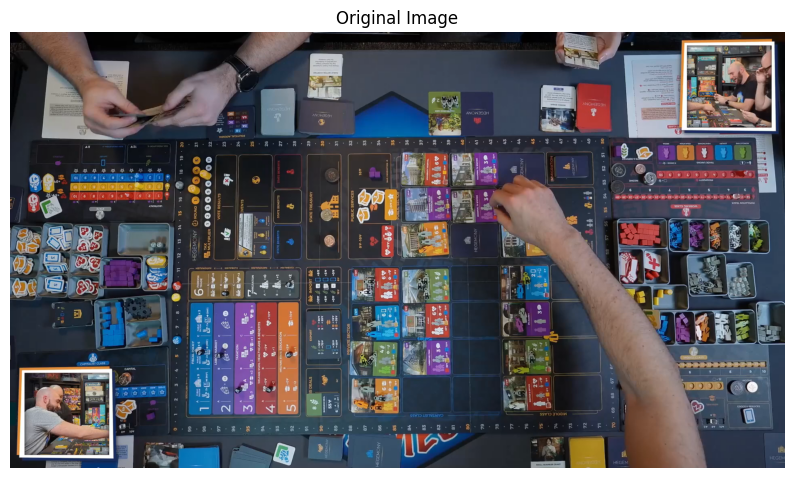

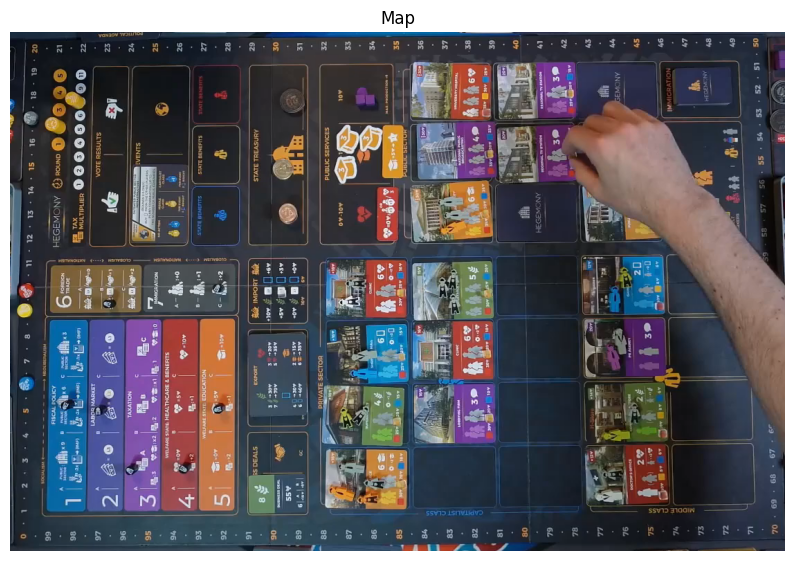

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10,8))

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


folder_path = "../dataset/Game_1/"

image_name = sorted(os.listdir(folder_path))[18]
img_path = os.path.join(folder_path, image_name)
img = cv2.imread(img_path)

# Find map 
x = 390
y = 255
w = 1120
h = 750
map = img[y:y+h, x:x+w]


print("Setup Complete. Tools are ready!")
print("Loaded:", image_name)
show_image(img, "Original Image")
show_image(map, "Map")

## Preprocessing


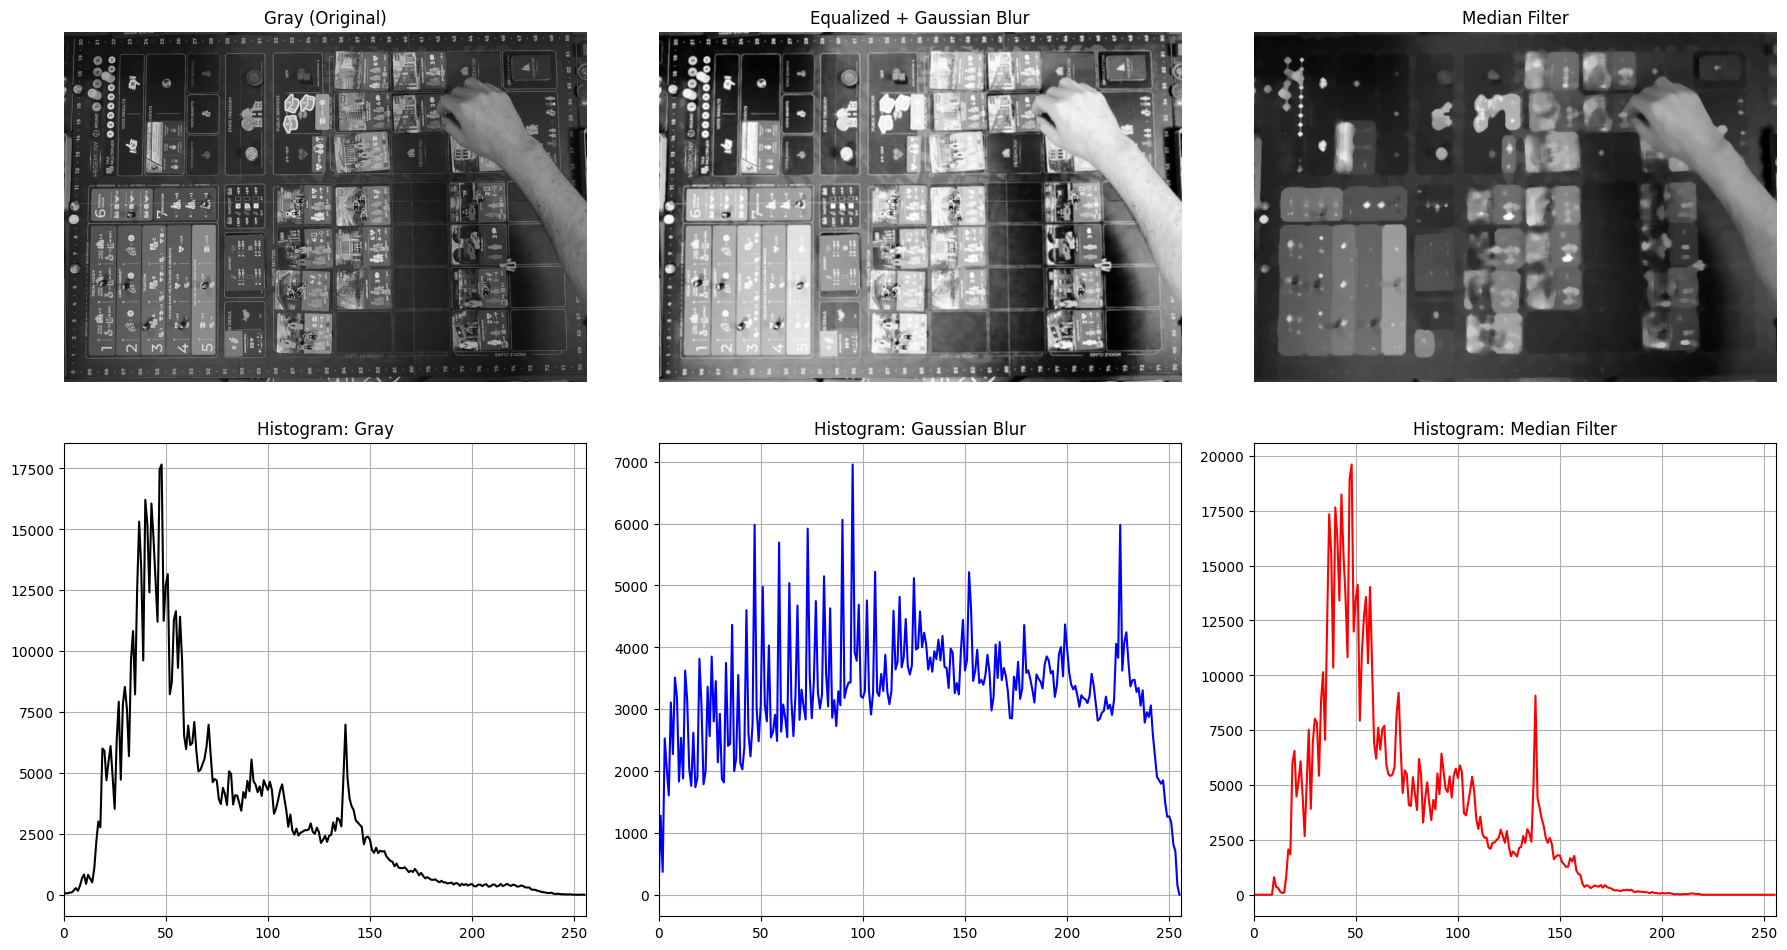

In [20]:
gray = cv2.cvtColor(map, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
blur_gaussian = cv2.GaussianBlur(equalized, (5, 5), 0)
blur_median = cv2.medianBlur(gray, 15)

hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_gaussian = cv2.calcHist([blur_gaussian], [0], None, [256], [0, 256])
hist_median = cv2.calcHist([blur_median], [0], None, [256], [0, 256])

# Display
plt.figure(figsize=(18, 10))

# Images
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Gray (Original)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(blur_gaussian, cmap='gray')
plt.title("Equalized + Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(blur_median, cmap='gray')
plt.title("Median Filter")
plt.axis("off")

# Histogrames
plt.subplot(2, 3, 4)
plt.plot(hist_gray, color='black')
plt.title("Histogram: Gray")
plt.xlim([0, 256])
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(hist_gaussian, color='blue')
plt.title("Histogram: Gaussian Blur")
plt.xlim([0, 256])
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(hist_median, color='red')
plt.title("Histogram: Median Filter")
plt.xlim([0, 256])
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation of Edge Detection Operators vs. Color Segmentation


Processing manual operators...
Processing complete!


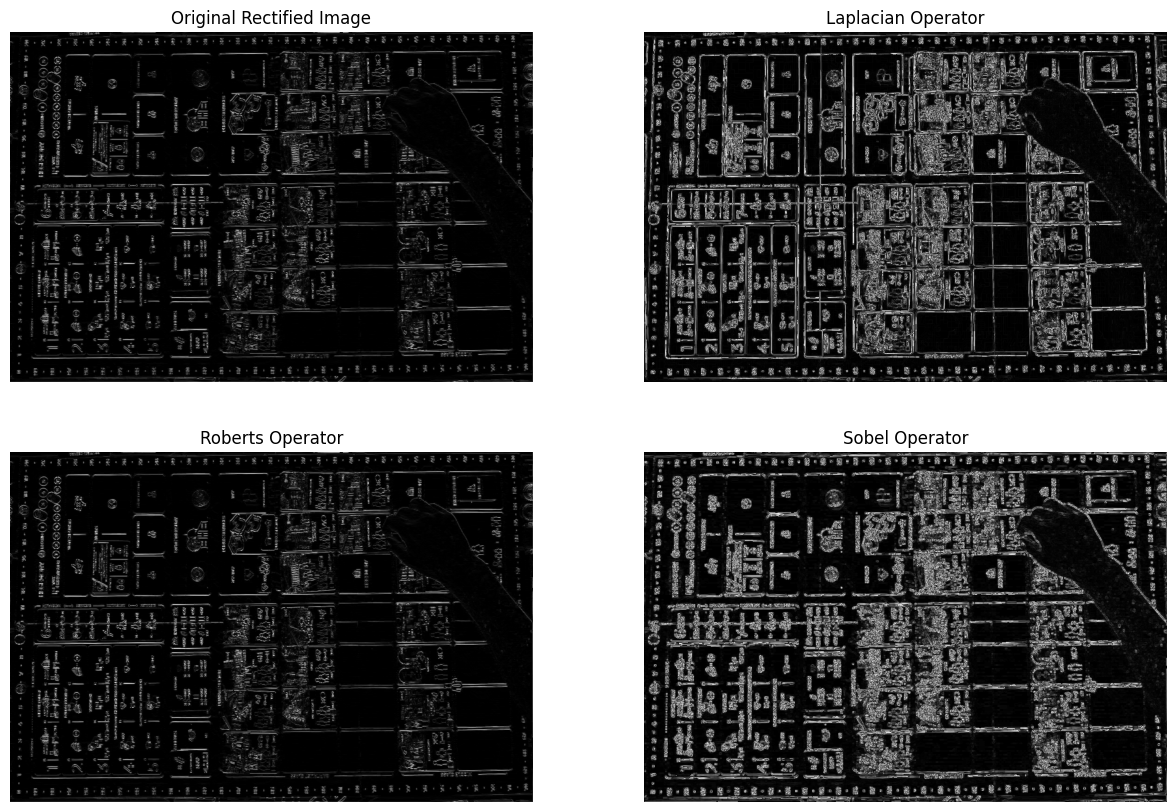

In [21]:
# Robert Operator
def robert(img):
    r, c = img.shape
    r_sunnzi = [[-1,-1],[1,1]]
    for x in range(r):
        for y in range(c):
            if (y + 2 <= c) and (x + 2 <= r):
                imgChild = img[x:x+2, y:y+2]
                list_robert = r_sunnzi*imgChild
                img[x, y] = abs(list_robert.sum()) # sum and absolute value
    return img

# Sobel Operator
def sobel(img):
    r, c = img.shape
    new_image = np.zeros((r, c))
    new_imageX = np.zeros(img.shape)
    new_imageY = np.zeros(img.shape)
    s_suanziX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]) # X direction
    s_suanziY = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])     
    
    for i in range(r-2):
        for j in range(c-2):
            new_imageX[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * s_suanziX))
            new_imageY[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * s_suanziY))
            new_image[i+1, j+1] = (new_imageX[i+1, j+1]**2 + new_imageY[i+1, j+1]**2)**0.5

    return np.uint8(new_image) # The image processed by the directionless operator

# Laplace Operator
def laplace(img):
    r, c = img.shape
    new_image = np.zeros((r, c))
    L_sunnzi = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]) # modify to find numbers       
    for i in range(r-2):
        for j in range(c-2):
            new_image[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * L_sunnzi))
    return np.uint8(new_image)

print("Processing manual operators...")
img_laplace = laplace(gray)
img_robert  = robert(gray)
img_sobel   = sobel(gray)
print("Processing complete!")

plt.figure(figsize=(15, 10))

plt.subplot(221)
plt.title("Original Rectified Image")
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.subplot(222)
plt.title("Laplacian Operator")
plt.imshow(img_laplace, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.subplot(223)
plt.title("Roberts Operator")
plt.imshow(img_robert, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.subplot(224)
plt.title("Sobel Operator")
plt.imshow(img_sobel, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.show()


## Edge Detection 


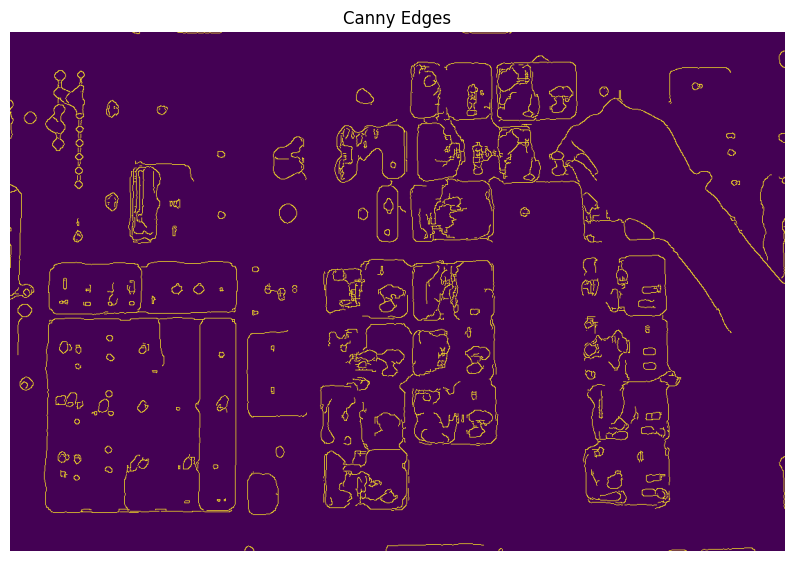

In [22]:
edges = cv2.Canny(blur_median, 30, 100)

show_image(edges, "Canny Edges") # if you want black and white use (...,cmap='gray')

## Token Detection and Spatial Localization


=== FILTRAGGIO MORFOLOGICO AVANZATO ===

=== RESOCONTO FINALE ===
Numeri individuati: 167
Pedine individuate: 9


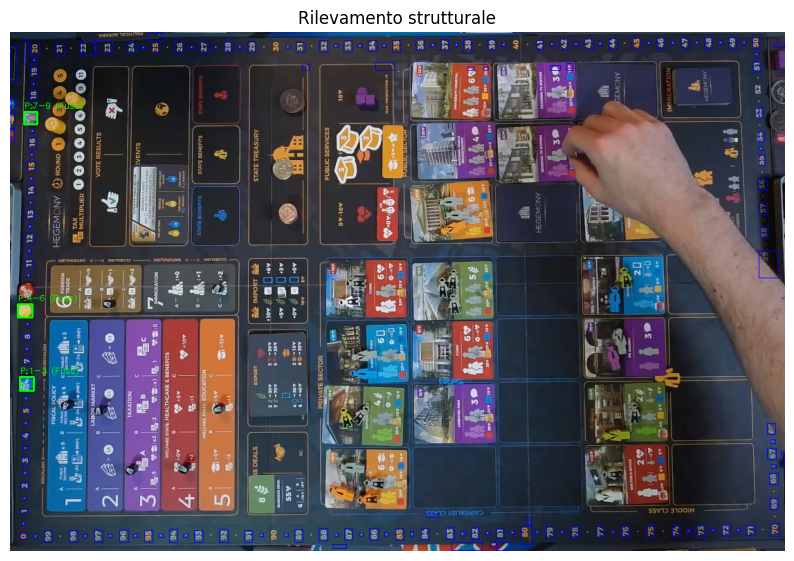

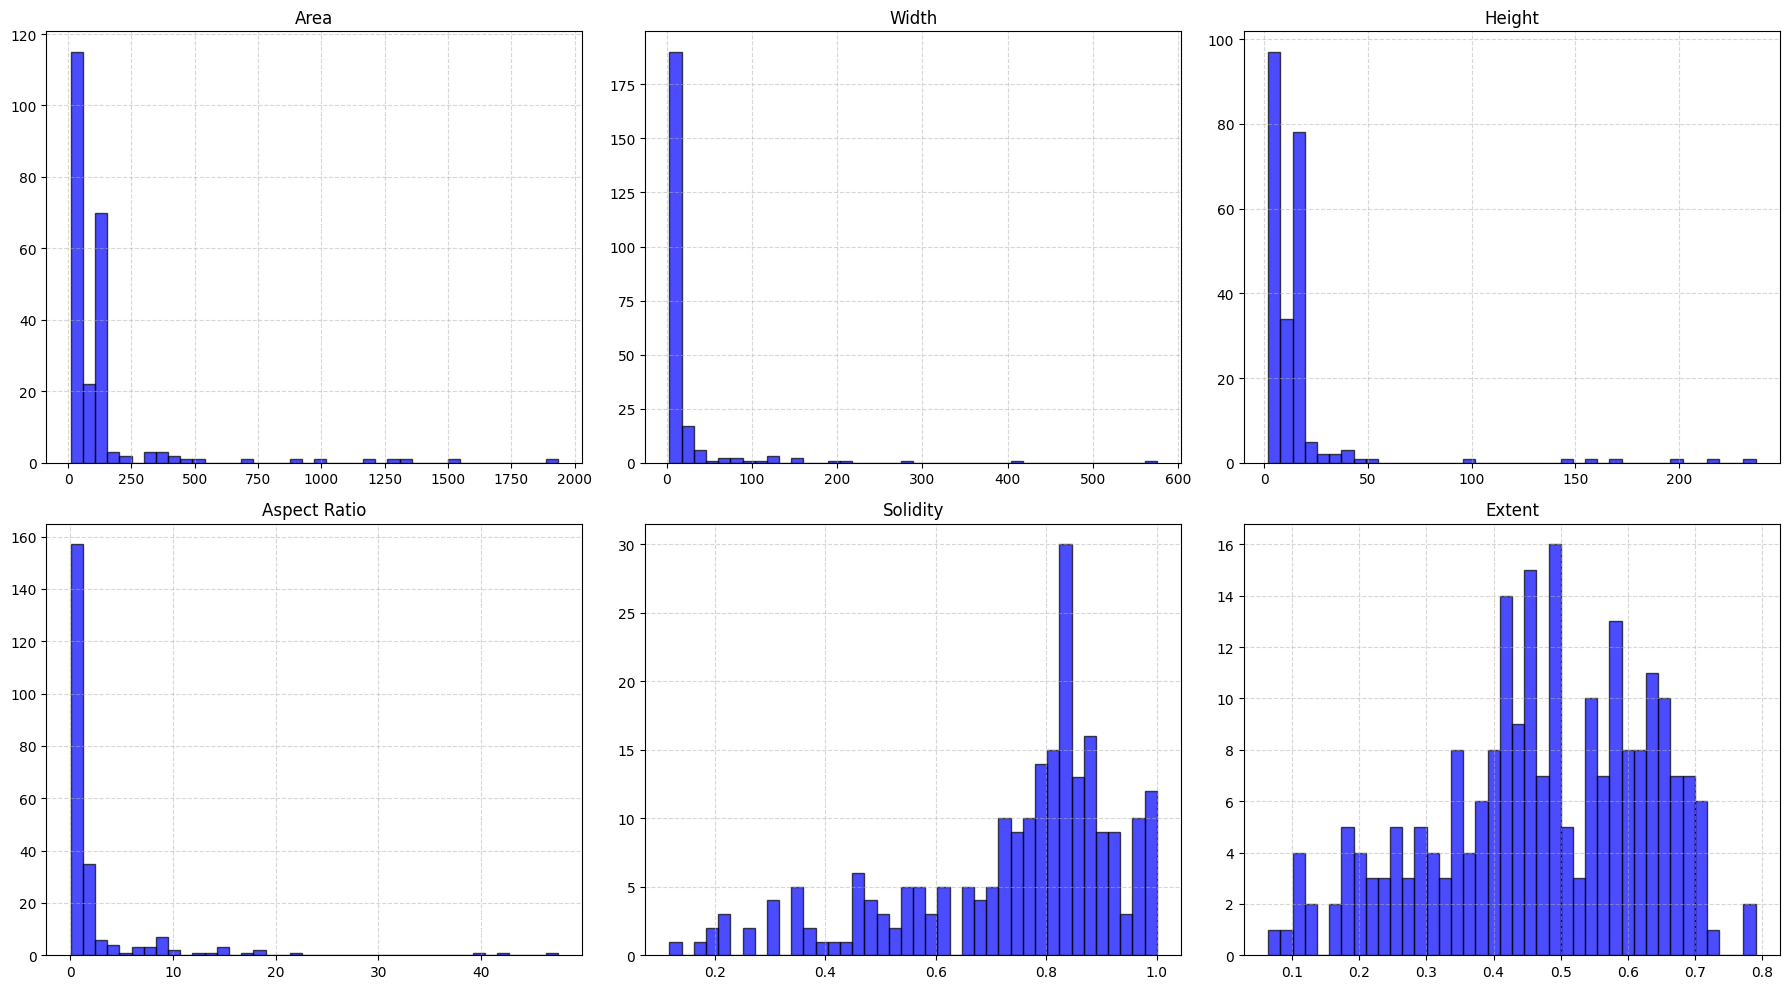

In [27]:
# --- STEP 5: PIPELINE STRUTTURALE CON FILTRO DI SOLIDITY ---

output_map = map.copy()
h, w = gray.shape

# ==========================================================
# ROI
# ==========================================================
border_top = 55
border_bottom = 54
border_left = 40
border_right = 38

roi_mask = np.zeros_like(gray)

roi_mask[0:border_top, :] = 255
roi_mask[h-border_bottom:h, :] = 255
roi_mask[:, 0:border_left] = 255
roi_mask[:, w-border_right:w] = 255

print("=== FILTRAGGIO MORFOLOGICO AVANZATO ===")

# ==========================================================
# LISTE PER ANALISI STATISTICA E STRUTTURE DATI LOGICHE
# ==========================================================
areas = []
widths = []
heights = []
aspect_ratios = []
solidities = []
extents = []

lista_numeri = []  # Conterrà tuple: (x, y, box_w, box_h) dei numeri validati
lista_pedine = []  # Conterrà tuple: (cX, cY) delle pedine validate

# ==========================================================
# TRACCIA A : NUMERI
# ==========================================================
_, binary_laplace = cv2.threshold(
    img_laplace,
    35,
    255,
    cv2.THRESH_BINARY
)

mask_numbers = cv2.bitwise_and(binary_laplace, roi_mask)

contours_num, _ = cv2.findContours(
    mask_numbers,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

num_boxes_count = 0

for cnt in contours_num:
    area = cv2.contourArea(cnt)

    if area < 10:
        continue

    x, y, box_w, box_h = cv2.boundingRect(cnt)

    if box_h == 0 or box_w == 0:
        continue

    aspect_ratio = box_w / box_h
    box_area = box_w * box_h
    extent = area / box_area

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)

    if hull_area > 0:
        solidity = area / hull_area
    else:
        solidity = 0

    # Salvataggio parametri generali per istogrammi
    areas.append(area)
    widths.append(box_w)
    heights.append(box_h)
    aspect_ratios.append(aspect_ratio)
    solidities.append(solidity)
    extents.append(extent)

    # ==========================
    # FILTRI CHIRURGICI NUMERI
    # ==========================
    if 10 < area < 3500:
        if 4 < box_h < 55 and 4 < box_w < 150:
            if 0.15 < aspect_ratio < 4.0:
                if solidity > 0.35:
                    num_boxes_count += 1
                    cv2.rectangle(
                        output_map,
                        (x, y),
                        (x + box_w, y + box_h),
                        (255, 0, 0),
                        1
                    )
                    # SALVIAMO IL NUMERO VALIDO PER LO STEP 6
                    lista_numeri.append((x, y, box_w, box_h))

# ==========================================================
# TRACCIA B : PEDINE (CORRETTA)
# ==========================================================

mask_tokens = cv2.bitwise_and(edges, roi_mask)

contours_tok, _ = cv2.findContours(
    mask_tokens,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

detected_tokens = 0
lista_pedine = []  # Svuotiamo e reinizializziamo per sicurezza

for cnt in contours_tok:
    area = cv2.contourArea(cnt)

    # FIX 1: Alziamo il tetto massimo dell'area a 500 per far entrare il braccio nel ciclo,
    # in modo che possa essere intercettato e segato dal filtro dimensionale successivo.
    if 20 < area < 500:
        x, y, box_w, box_h = cv2.boundingRect(cnt)

        if box_h == 0 or box_w == 0:
            continue

        aspect_ratio = box_w / box_h

        # VINCOLO CHIRURGICO ANTI-BRACCIO: 
        # Qualsiasi ROI più larga o alta di 42 pixel viene distrutta istantaneamente.
        if box_w > 42 or box_h > 42:
            continue 

        if 0.5 < aspect_ratio < 1.8:
            
            # FIX 2: Ritaratura geometrica dell'area basata sull'immagine reale.
            # Una pedina singola si aggira sui 40-60px. La sovrapposizione parziale 
            # (come quella sul tracciato a sinistra) genera blob intorno agli 85-110px.
            if area > 170:
                pedine_nel_contorno = 3
            elif area > 85:
                pedine_nel_contorno = 2
            else:
                pedine_nel_contorno = 1

            token_iniziale_blocco = detected_tokens + 1
            detected_tokens += pedine_nel_contorno

            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
            else:
                cX = x + box_w // 2
                cY = y + box_h // 2

            # Disegna solo se è una vera pedina filtrata
            cv2.rectangle(output_map, (x, y), (x + box_w, y + box_h), (0, 255, 0), 2)

            if pedine_nel_contorno > 1:
                testo_label = f"P:{token_iniziale_blocco}-{detected_tokens} (Fusa)"
            else:
                testo_label = f"P:{detected_tokens}"

            cv2.putText(output_map, testo_label, (x, y - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            
            for _ in range(pedine_nel_contorno):
                lista_pedine.append((cX, cY))

# ==========================================================
# RISULTATI
# ==========================================================
print("\n=== RESOCONTO FINALE ===")
print(f"Numeri individuati: {num_boxes_count}")
print(f"Pedine individuate: {detected_tokens}")

show_image(output_map, "Rilevamento strutturale")

# ==========================================================
# ISTOGRAMMI PER LA TARATURA (Griglia compatta)
# ==========================================================
plt.figure(figsize=(18, 10))

plt.subplot(231)
plt.title("Area")
plt.hist(areas, bins=40, color='blue', edgecolor='black', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(232)
plt.title("Width")
plt.hist(widths, bins=40, color='blue', edgecolor='black', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(233)
plt.title("Height")
plt.hist(heights, bins=40, color='blue', edgecolor='black', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(234)
plt.title("Aspect Ratio")
plt.hist(aspect_ratios, bins=40, color='blue', edgecolor='black', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(235)
plt.title("Solidity")
plt.hist(solidities, bins=40, color='blue', edgecolor='black', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(236)
plt.title("Extent")
plt.hist(extents, bins=40, color='blue', edgecolor='black', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Results of the game 

In [28]:
print("=== ELABORAZIONE LOGICA DELLE VERE PEDINE ===")

NUMERO_GIOCATORI_REALI = 4  
X_START_ZONE = 45   
Y_START_ZONE = h - 60 

stato_pedine = {}
classifica = []

# Analizziamo le pedine stimate rimaste dopo il super filtro anti-braccio
for idx in range(NUMERO_GIOCATORI_REALI):
    if idx < len(lista_pedine):
        cX, cY = lista_pedine[idx]
        
        # Controllo se è ancora allo start
        if abs(cX - X_START_ZONE) < 50 and abs(cY - Y_START_ZONE) < 50:
            punti = 0
            stato = "In attesa allo Start"
        else:
            # Calcolo distanza minima dalle caselle numeriche stimate
            distanza_minima = float('inf')
            casella_id = 0
            for num_idx, (nx, ny, nw, nh) in enumerate(lista_numeri):
                ncX = nx + nw // 2
                ncY = ny + nh // 2
                distanza = ((cX - ncX)**2 + (cY - ncY)**2)**0.5
                if distanza < distanza_minima:
                    distanza_minima = distanza
                    casella_id = num_idx + 1 # Associazione all'indice della casella
            
            punti = casella_id
            stato = "In movimento"
            
        stato_pedine[f"Pedina_{idx+1}"] = {"punti": punti, "stato": stato}
    else:
        # Se OpenCV ha perso una pedina per via della mano sopra, la lasciamo a zero o all'ultimo stato noto
        stato_pedine[f"Pedina_{idx+1}"] = {"punti": 0, "stato": "Coperta dalla mano / Non rilevata"}

# Stampa Risultati
for nome, info in stato_pedine.items():
    print(f"{nome} -> Punteggio: {info['punti']} ({info['stato']})")

=== ELABORAZIONE LOGICA DELLE VERE PEDINE ===
Pedina_1 -> Punteggio: 75 (In movimento)
Pedina_2 -> Punteggio: 75 (In movimento)
Pedina_3 -> Punteggio: 75 (In movimento)
Pedina_4 -> Punteggio: 79 (In movimento)
